In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Node, Material,
    # Sections
    Membrane,
    # Elements
    CST, LST, Quad4, Quad9,
    # Gmsh tools
    read_mesh, build_nodes, build_elements, build_load_vector,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d,
    # Units
    mm, cm, m, kgf, N, tf, kN, MPa, GPa, kg,
    # Parameters
    globalParameters,
)
# Standard libraries
import os
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 0.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
# General model parameters
L = 5000 
H = 500  
B = 300
lc = 100
output_path = os.getcwd()
mesh_name = 'calibrated_beam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Corner points
p1 = gmsh.model.geo.addPoint(0,   0, 0, lc)
p2 = gmsh.model.geo.addPoint(L,   0, 0, lc)
p3 = gmsh.model.geo.addPoint(L,   H, 0, lc)
p4 = gmsh.model.geo.addPoint(0,   H, 0, lc)

# Mid points (bottom and top)
p5 = gmsh.model.geo.addPoint(L/2, 0, 0, lc)
p6 = gmsh.model.geo.addPoint(L/2, H, 0, lc)

# Lines
l1 = gmsh.model.geo.addLine(p1, p5)  # Bottom left
l2 = gmsh.model.geo.addLine(p5, p2)  # Bottom right
l3 = gmsh.model.geo.addLine(p2, p3)  # Right side
l4 = gmsh.model.geo.addLine(p3, p6)  # Top right
l5 = gmsh.model.geo.addLine(p6, p4)  # Top left
l6 = gmsh.model.geo.addLine(p4, p1)  # Left side
l7 = gmsh.model.geo.addLine(p5, p6)  # Center vertical

# Surfaces
c1 = gmsh.model.geo.addCurveLoop([l1,  l7, l5, l6])  # Left half
s1 = gmsh.model.geo.addPlaneSurface([c1])

c2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l7])  # Right half
s2 = gmsh.model.geo.addPlaneSurface([c2])

gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(2, [s1, s2], 201)
gmsh.model.setPhysicalName(2, 201, "Beam")

gmsh.model.addPhysicalGroup(0, [p1], 101)
gmsh.model.setPhysicalName(0, 101, "Support_left")

gmsh.model.addPhysicalGroup(0, [p2], 102)
gmsh.model.setPhysicalName(0, 102, "Support_right")

gmsh.model.addPhysicalGroup(0, [p6], 50)
gmsh.model.setPhysicalName(0, 50, "Load")

gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

all_quads()

In [5]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [6]:
# Define material
fc_21 = Material(name='fc_21',
                 E=19185.1,
                 nu=0.20,
                 rho=1.25)

# Define membrane section
ConcreteBeam = Membrane(name='ConcreteBeam',
                        thickness=300,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteBeam}

# Define distributed load magnitude
Pload = 98066.5

load_dictionary = {
    50:  {'value': Pload, 'direction': '-y'},   
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       102: ['f', 'r']}


In [7]:
# Read raw mesh data from gmsh file
mesh = read_mesh(output_file)

# Instantiate Node objects and apply boundary conditions
node_map, nodes = build_nodes(mesh, restrain_dictionary)

In [8]:
import json

# mesh structure
print("=== NODES ===")
node_items = list(mesh['nodes'].items())[:5]
for tag, coords in node_items:
    print(f"  tag={tag:4d}  coords={coords}")

print("\n=== PHYSICAL GROUPS ===")
for phys_id, info in mesh['physical_groups'].items():
    print(f"  phys_id={phys_id:4d}  dim={info['dim']}  name='{info['name']}'")

print("\n=== ELEMENTS ===")
for phys_id, group in mesh['elements'].items():
    name = mesh['physical_groups'][phys_id]['name']
    print(f"  phys_id={phys_id:4d}  name='{name}'  dim={group['dim']}  gmsh_type={group['gmsh_type']}  n_nodes={group['n_nodes']}  n_elements={len(group['element_tags'])}")

=== NODES ===
  tag=   1  coords=(0.0, 0.0, 0.0)
  tag=   2  coords=(5000.0, 0.0, 0.0)
  tag=   3  coords=(5000.0, 500.0, 0.0)
  tag=   4  coords=(0.0, 500.0, 0.0)
  tag=   5  coords=(2500.0, 0.0, 0.0)

=== PHYSICAL GROUPS ===
  phys_id=  50  dim=0  name='Load'
  phys_id= 101  dim=0  name='Support_left'
  phys_id= 102  dim=0  name='Support_right'
  phys_id= 201  dim=2  name='Beam'

=== ELEMENTS ===
  phys_id=  50  name='Load'  dim=0  gmsh_type=15  n_nodes=1  n_elements=1
  phys_id= 101  name='Support_left'  dim=0  gmsh_type=15  n_nodes=1  n_elements=1
  phys_id= 102  name='Support_right'  dim=0  gmsh_type=15  n_nodes=1  n_elements=1
  phys_id= 201  name='Beam'  dim=2  gmsh_type=3  n_nodes=4  n_elements=312


In [9]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Instantiate FEM element objects from mesh connectivity
elements = build_elements(  mesh=mesh,
                            node_map=node_map,
                            section_dictionary=section_dictionary,
                            element_class_map=element_map )

In [10]:
# Setup system parameters
nodeList = nodes
elementList = elements

# Get total number of nodes and elements
nNodes = len(nodeList)
nElements = len(elementList)

# Define degrees of freedom per node (x, y displacements)
globalParameters = {'nDoF': 2}

# Calculate total system degrees of freedom
system_nDof = 2 * nNodes

In [11]:
# Build global nodal force vector from load dictionary
F_load = build_load_vector(mesh=mesh, 
                            node_map=node_map, 
                            load_dictionary=load_dictionary, 
                            system_nDof=system_nDof)

In [12]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elementList:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodeList:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodeList])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Remove load on restrained DOFs (they go to reactions directly)
F[restrained_dofs] = 0.0

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [13]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [14]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [5000.  500.]:  ux=+0.019901  uy=-0.038304
Node 102 at [961.538462 500.      ]:  ux=+1.178954  uy=-2.367393


In [15]:
# Reactions per node
for node in nodeList:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-0.000000  Ry=+49033.250000
Node 2:  Rx=+0.000000  Ry=+49033.250000
----------------------------------------------------------------------------------------------------
Applied X:  -0.0000   Reaction X: -0.0000   Balance: -8.0798e-09
Applied Y:  -98066.5000   Reaction Y: +98066.5000   Balance: -1.4645e-07


In [16]:
for node in nodes:
    fx = F_load[node.idx[0]]
    fy = F_load[node.idx[1]]
    if abs(fx) > 0 or abs(fy) > 0:
        print(f"Node {node.name} at {node.coordinates}:  Fx={fx:+.4f}  Fy={fy:+.4f}")

Node 6 at [2500.  500.]:  Fx=-0.0000  Fy=-98066.5000


In [17]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [18]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

2

In [19]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [20]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [21]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [22]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

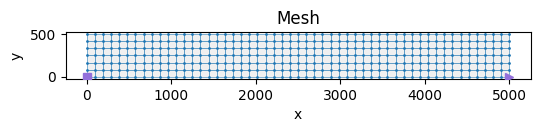

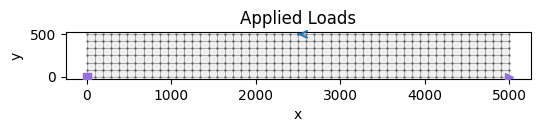

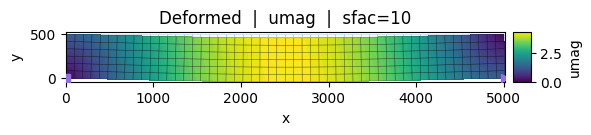

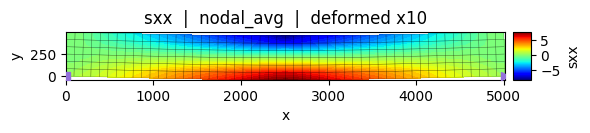

In [ ]:
# Mesh
plot_mesh(
    nodes               = nodes,
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,   
)


# Loads
plot_loads_2d(
    nodes    = nodes,
    elements = elements,
    F_load   = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize  = (6, 6),
    ax       = None,
    save     = None,    
)

# Deformed
plot_deformed(
    nodes     = nodes,
    elements  = elements,
    u         = u,
    component = 'umag',   # 'ux', 'uy', 'umag'
    sfac      = 10,
    cmap      = 'viridis',
    limit               = None,      
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes       = nodes,
    elements    = elements,
    u           = u,
    component   = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed    = True,
    sfac        = 10,
    limit       = None,         # e.g. (-250, 250) highlights elements outside range in red
    # levels      = 20,
    cmap        = 'jet',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (6, 6),
    ax                  = None,
    save                = None,
)